# CVaR-Based Portfolio Optimization
**MSBA Optimization — Project 1 — Group 11**
Emma Trunnell, Nathan Arimilli, Nikhil Kumar, Satvik Shankar

This notebook builds a **linear program** that minimizes the **Conditional Value-at-Risk
(CVaR / Expected Shortfall)** of a long-only stock portfolio. We train on 2019 NASDAQ-100
returns and stress-test on the 2020 COVID shock.

All model functions are imported from [`cvar_portfolio.py`](cvar_portfolio.py) so the notebook
and the standalone script share **one** implementation. Running `cvar_portfolio.py` also writes
the full set of labelled figures and result tables to `../output/`.

## Setup & data load
> **Graders:** the only inputs are the two CSV paths below — change them to re-run on new data.
> Everything downstream is computed from variables, with no hard-coded numbers.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# Core model + evaluation functions (single source of truth)
from cvar_portfolio import (
    prepare_returns, solve_cvar_lp, solve_minimax_monthly_cvar,
    evaluate_portfolio, cvar_var, diversification, BETA, RMIN,
)
# cvar_portfolio sets a headless backend for script use; switch to inline for the notebook
%matplotlib inline
import matplotlib.pyplot as plt

# >>> CSV INPUTS (edit these two lines to re-grade on new data) <<<
prices_2019 = pd.read_csv("../data/stocks2019.csv")
prices_2020 = pd.read_csv("../data/stocks2020.csv")

rets_train, rets_test, ndx_train, ndx_test, symbols = prepare_returns(prices_2019, prices_2020)
print(f"Train {rets_train.index.year.min()}: {rets_train.shape}   "
      f"Test {rets_test.index.year.min()}: {rets_test.shape}")
print(f"Investable universe: {len(symbols)} assets   beta={BETA}   R={RMIN:.2%}/day")

Train 2019: (250, 100)   Test 2020: (251, 100)
Investable universe: 100 assets   beta=0.95   R=0.02%/day


## The model (Rockafellar–Uryasev linear program)

**Sets / indices**  $j=1,\dots,N$ assets;  $k=1,\dots,T$ daily return scenarios.
**Parameters**  $y_{kj}$ return of asset $j$ on day $k$; $\mu_j$ mean return of $j$;
$\beta$ confidence level; $R$ minimum daily expected return.
**Decision variables**  $x_j\ge 0$ portfolio weights; $\alpha$ VaR variable; $u_k\ge 0$ tail-loss slacks.

$$\min_{x,\alpha,u}\;\; \alpha + \frac{1}{(1-\beta)T}\sum_{k=1}^{T} u_k$$

$$\text{s.t.}\quad u_k \ge -\textstyle\sum_j x_j y_{kj} - \alpha,\quad u_k\ge 0\;\;\forall k;\qquad
\sum_j x_j = 1;\qquad \sum_j \mu_j x_j \ge R;\qquad 0\le x_j\le 1.$$

We evaluate every portfolio's CVaR with the **same** definition the LP minimizes:
$\text{VaR}=$ the $\beta$-quantile of losses, and
$\text{CVaR}=\text{VaR}+\frac{1}{1-\beta}\mathbb{E}\big[(\text{loss}-\text{VaR})_+\big]$.

## Task 2 — Baseline ($\beta=0.95$, $R=0.02\%$): train 2019, test 2020, vs NDX

In [2]:
sol2  = solve_cvar_lp(rets_train, beta=BETA, R=RMIN)
e_in  = evaluate_portfolio(sol2["x"], rets_train, beta=BETA)
e_out = evaluate_portfolio(sol2["x"], rets_test,  beta=BETA)
ndx_in  = cvar_var(ndx_train.values, BETA)
ndx_out = cvar_var(ndx_test.values,  BETA)

pct = lambda v: f"{100*v:.2f}%"
summary = pd.DataFrame({
    "Optimized 2019": [e_in['avg_daily_return'], e_in['std_daily_return'], e_in['VaR_beta_loss'], e_in['CVaR_beta_loss']],
    "Optimized 2020": [e_out['avg_daily_return'], e_out['std_daily_return'], e_out['VaR_beta_loss'], e_out['CVaR_beta_loss']],
    "NDX 2019":       [ndx_train.mean(), ndx_train.std(), ndx_in[0],  ndx_in[1]],
    "NDX 2020":       [ndx_test.mean(),  ndx_test.std(),  ndx_out[0], ndx_out[1]],
}, index=["Avg daily return","Volatility","VaR (loss)","CVaR (loss)"]).map(pct)
display(summary)

d2 = diversification(sol2['x'])
print(f"Optimized portfolio: {d2['n_holdings']} holdings, effective N = {d2['effective_N']:.1f}")
display(pd.Series(sol2['x'], index=sol2['assets']).sort_values(ascending=False).head(8).map(pct).to_frame("Top holdings"))

Restricted license - for non-production use only - expires 2026-11-23


,Optimized 2019,Optimized 2020,NDX 2019,NDX 2020
Avg daily return,0.12%,0.10%,0.13%,0.17%
Volatility,0.68%,1.94%,1.03%,2.30%
VaR (loss),0.85%,2.53%,1.60%,3.90%
CVaR (loss),1.11%,4.66%,2.48%,5.65%


Optimized portfolio: 13 holdings, effective N = 5.4


,Top holdings
XEL,30.39%
CHTR,26.50%
AMGN,8.08%
CTXS,6.56%
CHKP,6.27%
EXC,5.22%
KHC,4.05%
CSX,3.43%


The optimized portfolio carries **lower tail risk than NDX in both years**, but the absolute
CVaR jumps from ~1.1% (2019) to ~4.7% (2020): a static 2019 allocation does **not** transfer to the
non-stationary 2020 regime. The cumulative-return view shows the trade-off — a shallower March
drawdown bought with less upside in the recovery.

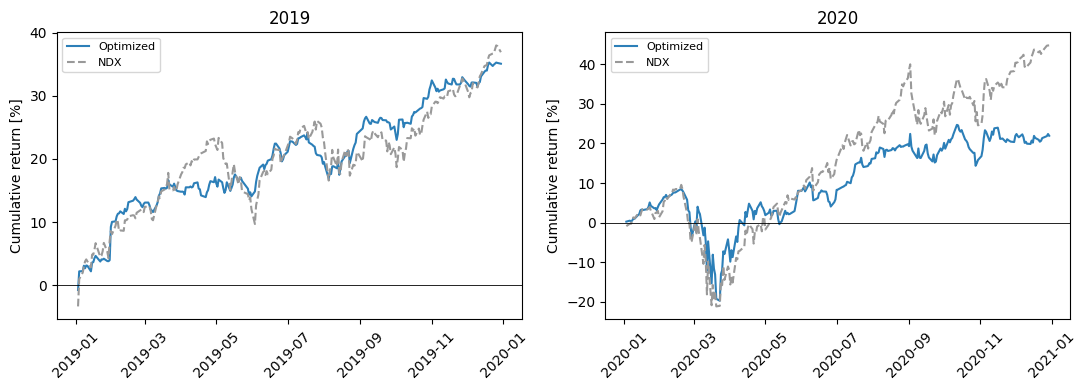

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for ax,(rp,rb,idx,yr) in zip(axes,[(e_in['port_returns'],ndx_train.values,rets_train.index,2019),
                                    (e_out['port_returns'],ndx_test.values,rets_test.index,2020)]):
    ax.plot(idx, (np.cumprod(1+rp)-1)*100, label="Optimized", color="#2c7fb8")
    ax.plot(idx, (np.cumprod(1+rb)-1)*100, label="NDX", color="#999", ls="--")
    ax.axhline(0,color="k",lw=.6); ax.set_title(str(yr)); ax.set_ylabel("Cumulative return [%]")
    ax.legend(fontsize=8); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## Task 3 — Sensitivity to $\beta$  (and quantified diversification)

,2019 CVaR,2020 CVaR,Effective N,# holdings
beta=0.9,0.89%,3.27%,7.1,16
beta=0.95,1.11%,4.66%,5.4,13
beta=0.99,1.25%,9.66%,3.6,9


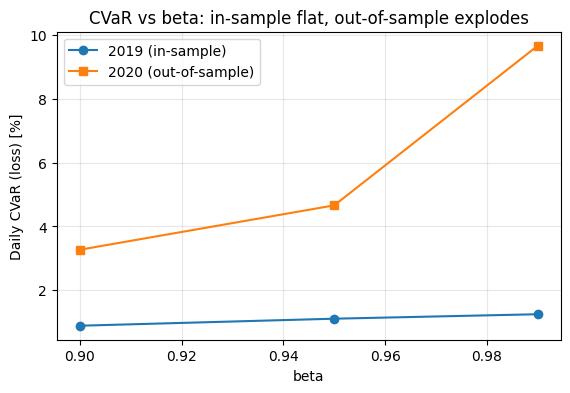

In [4]:
betas=(0.90,0.95,0.99); rows={}; allocs={}
for b in betas:
    sb=solve_cvar_lp(rets_train,beta=b,R=RMIN)
    ein=evaluate_portfolio(sb['x'],rets_train,beta=b); eout=evaluate_portfolio(sb['x'],rets_test,beta=b)
    dv=diversification(sb['x'])
    rows[f"beta={b}"]={"2019 CVaR":pct(ein['CVaR_beta_loss']),"2020 CVaR":pct(eout['CVaR_beta_loss']),
                       "Effective N":f"{dv['effective_N']:.1f}","# holdings":dv['n_holdings']}
    allocs[b]=pd.Series(sb['x'],index=sb['assets'])
display(pd.DataFrame(rows).T)

fig,ax=plt.subplots(figsize=(6.5,4))
ax.plot(betas,[float(rows[f'beta={b}']['2019 CVaR'][:-1]) for b in betas],"o-",label="2019 (in-sample)")
ax.plot(betas,[float(rows[f'beta={b}']['2020 CVaR'][:-1]) for b in betas],"s-",label="2020 (out-of-sample)")
ax.set_xlabel("beta"); ax.set_ylabel("Daily CVaR (loss) [%]"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("CVaR vs beta: in-sample flat, out-of-sample explodes"); plt.show()

Higher $\beta$ concentrates capital (effective holdings fall **7.1 → 5.4 → 3.6**) and looks great
in-sample, but **amplifies** out-of-sample losses — $\beta=0.99$ nearly **doubles** the 2020 CVaR vs
$\beta=0.95$. Tail-focus over-fits 2019.

## Task 4 — Minimax: minimize the worst month's CVaR in 2019

In [5]:
sol4=solve_minimax_monthly_cvar(rets_train,beta=BETA,R=RMIN)
e4=evaluate_portfolio(sol4['x'],rets_test,beta=BETA)
print(f"2019 worst-month CVaR (minimax objective): {pct(sol4['t'])}")
print(f"2020 daily CVaR of minimax weights:        {pct(e4['CVaR_beta_loss'])}  (baseline was {pct(e_out['CVaR_beta_loss'])})")

w_mm=pd.Series(sol4['x'],index=sol4['assets']); w99=allocs[0.99].reindex(w_mm.index).fillna(0)
cos=float(np.dot(w_mm,w99)/(np.linalg.norm(w_mm)*np.linalg.norm(w99)))
print(f"Cosine similarity (minimax vs beta=0.99 weights): {cos:.3f}  ->  essentially the same portfolio")

2019 worst-month CVaR (minimax objective): 1.24%
2020 daily CVaR of minimax weights:        4.73%  (baseline was 4.66%)
Cosine similarity (minimax vs beta=0.99 weights): 1.000  ->  essentially the same portfolio


The minimax allocation is **almost identical** to the $\beta=0.99$ allocation (cosine ≈ 1.00):
both push hard into the same defensive names (XEL, CHTR). Minimax tightens the worst-month guardrail
in-sample but barely changes 2020 tail risk — it is, in effect, another route to a very conservative,
concentrated tilt.

## Task 5 — Monthly re-optimization in 2020 (rolling 12-month window)

Rolling avg 3.23%  std 2.39%  min 0.81%  max 10.17% (2020-03)
Rolling beat the static 2019 portfolio in 5/12 months (static avg 2.94%).


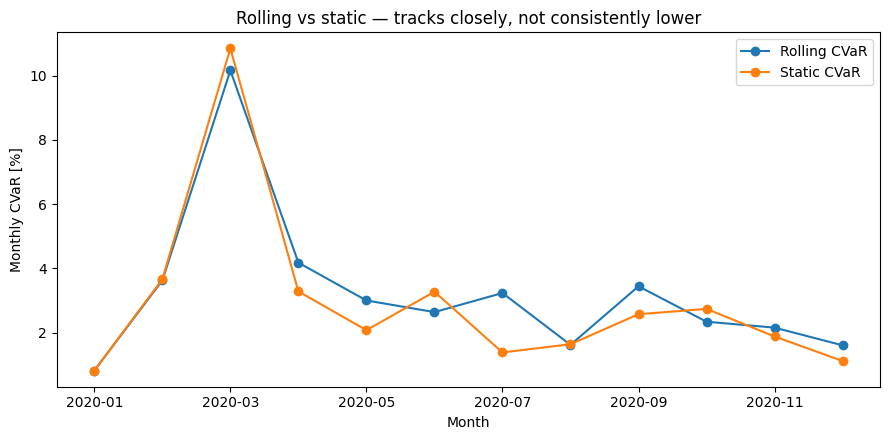

In [6]:
rets_all=pd.concat([rets_train,rets_test]); months_all=rets_all.index.to_period("M")
rows=[]; wbm={}
for mo in sorted(rets_test.index.to_period("M").unique()):
    win=rets_all[(months_all>=(mo-12))&(months_all<=(mo-1))]   # exactly the 12 prior months
    s=solve_cvar_lp(win,beta=BETA,R=RMIN)
    e =evaluate_portfolio(s['x'],    rets_all[months_all==mo],beta=BETA)  # rolling
    es=evaluate_portfolio(sol2['x'], rets_all[months_all==mo],beta=BETA)  # static 2019 weights
    rows.append({"Month":str(mo),"Rolling CVaR":e['CVaR_beta_loss'],"Static CVaR":es['CVaR_beta_loss']})
    wbm[str(mo)]=pd.Series(s['x'],index=s['assets'])
m5=pd.DataFrame(rows).set_index("Month")
print(f"Rolling avg {pct(m5['Rolling CVaR'].mean())}  std {pct(m5['Rolling CVaR'].std())}  "
      f"min {pct(m5['Rolling CVaR'].min())}  max {pct(m5['Rolling CVaR'].max())} ({m5['Rolling CVaR'].idxmax()})")
won=int((m5['Rolling CVaR']<m5['Static CVaR']).sum())
print(f"Rolling beat the static 2019 portfolio in {won}/{len(m5)} months "
      f"(static avg {pct(m5['Static CVaR'].mean())}).")
ax=(m5*100).plot(marker="o",figsize=(9,4.5)); ax.set_ylabel("Monthly CVaR [%]")
ax.set_title("Rolling vs static — tracks closely, not consistently lower"); plt.tight_layout(); plt.show()

**Honest reading:** on a like-for-like month-by-month basis, rolling re-optimization did **not**
reliably beat simply holding the 2019 portfolio — it won only ~5 of 12 months and its average monthly
CVaR was *slightly higher*. The single worst month (March 2020) dominates either way. Re-optimizing on
trailing data cannot anticipate a regime break; it mostly chases the last 12 months.

## Task 6 — Stability of the monthly allocations (≤ 5 pp)

In [7]:
months=list(wbm); srows=[]
for i in range(1,len(months)):
    d=(wbm[months[i]]-wbm[months[i-1]]).abs()
    srows.append({"from":months[i-1],"to":months[i],"Max change":pct(d.max()),
                  "Driver":d.idxmax(),"Stable":bool(d.max()<=0.05)})
stab=pd.DataFrame(srows); display(stab)
print(f"Share of stable (<=5pp) transitions: {100*stab['Stable'].mean():.1f}%")

,from,to,Max change,Driver,Stable
0,2020-01,2020-02,2.35%,EBAY,True
1,2020-02,2020-03,8.58%,AMGN,False
2,2020-03,2020-04,45.17%,CTXS,False
3,2020-04,2020-05,20.43%,CTXS,False
4,2020-05,2020-06,19.58%,CTXS,False
5,2020-06,2020-07,7.49%,MAR,False
6,2020-07,2020-08,13.05%,COST,False
7,2020-08,2020-09,29.00%,COST,False
8,2020-09,2020-10,19.59%,COST,False
9,2020-10,2020-11,6.84%,GILD,False


Share of stable (<=5pp) transitions: 18.2%


Only ~18% of month-to-month transitions stay within 5 pp; the biggest single move is ~45 pp
(into/out of CTXS around the March crash). The adaptiveness of Task 5 therefore comes with heavy
turnover. **To enforce stability** without re-deriving the model, add per-asset turnover bounds
$-0.05 \le x_{j,t}-x_{j,t-1} \le 0.05$, or penalize $\sum_j |x_{j,t}-x_{j,t-1}|$ in the objective —
both keep the LP linear.

## Key results

In [8]:
pd.read_csv("../output/key_results.csv", index_col=0)

,value
Task 2 - In-sample CVaR (2019),0.011090
Task 2 - Out-of-sample CVaR (2020),0.046568
Task 2 - NDX CVaR (2020),0.056499
Task 3 - Out-of-sample CVaR @ beta=0.99 (2020),0.096645
"Task 4 - Worst-month CVaR (2019, train)",0.012446
Task 4 - Out-of-sample daily CVaR (2020),0.047317
Task 5 - Avg monthly CVaR (2020),0.032334
Task 5 - Min monthly CVaR (2020),0.008140
Task 5 - Max monthly CVaR (2020),0.101672
Task 6 - Share of stable transitions,0.181818
